# Attention Map visualisations on sample Wheeze Spectrogram


shape: (514, 514) dtype: float32 min/max: 1.5922538e-05 0.2347527


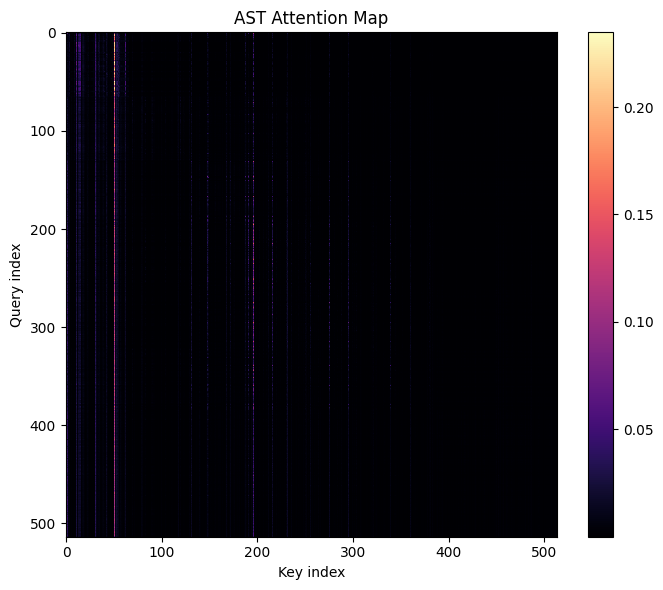

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

path = "/attention_maps/attention_map_ast_4.npy"
attn = np.load(path)

print("shape:", attn.shape, "dtype:", attn.dtype, "min/max:", attn.min(), attn.max())


plt.figure(figsize=(7, 6))
plt.imshow(attn, cmap="magma", aspect="auto", interpolation="nearest")
plt.title("AST Attention Map")
plt.xlabel("Key index")
plt.ylabel("Query index")
plt.colorbar()
plt.tight_layout()
plt.show()

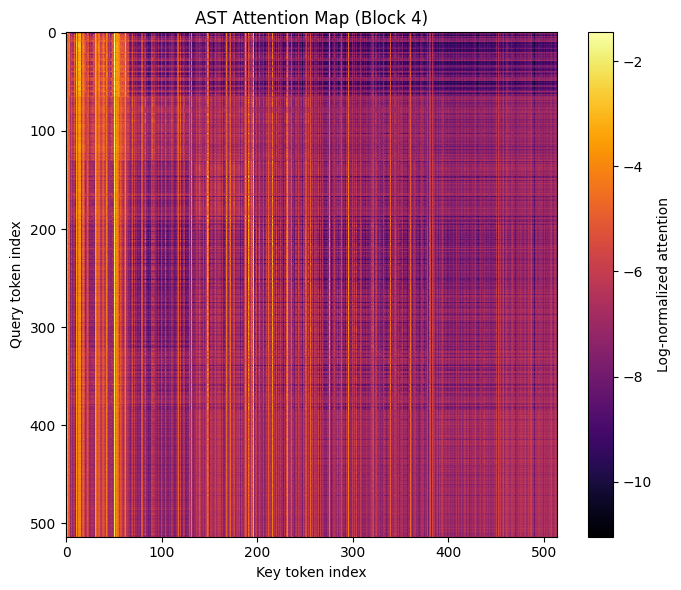

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


npy_path = "/attention_maps/attention_map_ast_4.npy"
attn = np.load(npy_path)


attn_log = np.log(attn)



plt.figure(figsize=(7, 6))
plt.imshow(attn_log, cmap="inferno", interpolation="nearest", aspect="auto")
plt.colorbar(label="Log-normalized attention")
plt.title("AST Attention Map (Block 4)")
plt.xlabel("Key token index")
plt.ylabel("Query token index")
plt.tight_layout()
plt.show()

# Spectral Filter Response Curve 
- **What you need:**
    - `Attention Matrix`: The attention matrix after applying the softmax function. In this code, we use an attention matrix with the shape (batch, n_heads, N, N), where N is the maximum sequence length .
   
- **How to calculate:**
    - We follow the procedure outlined in Appendix F.2 of the paper *Anti-Oversmoothing in Deep Vision Transformers via the Fourier Domain Analysis: From Theory to Practice* (ICLR 2022).
    - By treating the attention matrix $A$ as a linear filter, its Fourier-domain response can be represented by another linear kernel, $\Lambda = F A F^{-1}$, where $F$ is the Fourier transform matrix.

loaded: (514, 514) float32


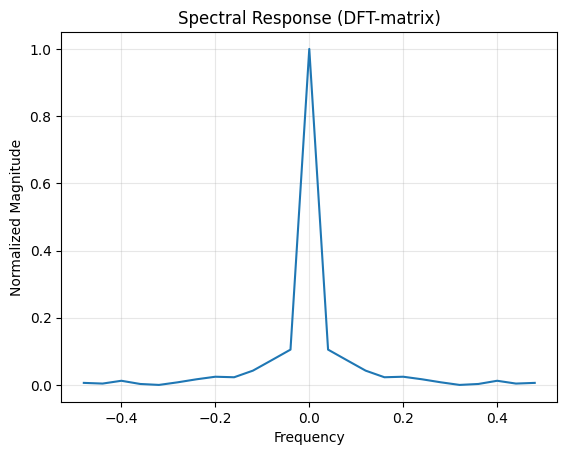

In [ ]:
import numpy as np
import scipy
from scipy.linalg import dft
import matplotlib.pyplot as plt

file_path = "/attention_maps/attention_map_ast_4.npy"
attn = np.load(file_path)
print("loaded:", attn.shape, attn.dtype)

L = attn.shape[0]

def fftshift(arr, n=50):

    freq = scipy.fft.rfftfreq(25)
    x = np.concatenate([np.flip(-freq[1:]), freq])
    y = np.concatenate([np.flip(arr[1:]), arr])

    return x, y

F = dft(L)                 
Finv = np.linalg.inv(F)   

spec = F @ attn @ Finv
spec_1d = np.abs(spec).mean(axis=1)
spec_1d = spec_1d[:13]

x, y = fftshift(spec_1d, n=26)
y = (y - y.min()) / (y.max() - y.min() + 1e-12)

plt.title("Spectral Response (DFT-matrix)")
plt.xlabel("Frequency")
plt.ylabel("Normalized Magnitude")
plt.plot(x, y)
plt.grid(alpha=0.3)
plt.show()

loaded: (514, 514) float32


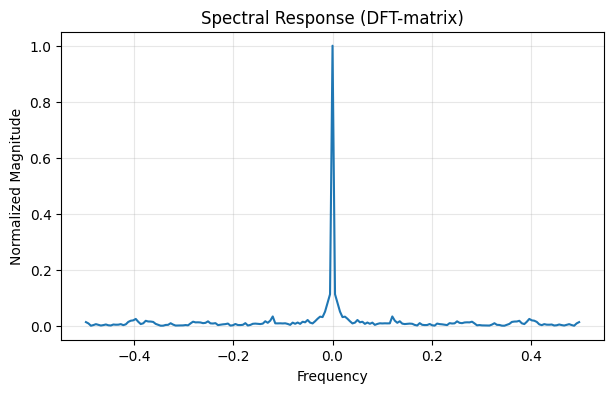

In [ ]:
import numpy as np
import scipy
from scipy.linalg import dft
import matplotlib.pyplot as plt

file_path = "/attention_maps/attention_map_ast_4.npy"
attn = np.load(file_path)
print("loaded:", attn.shape, attn.dtype)

L = attn.shape[0]

def fftshift(arr):
    N = len(arr)
    freq = scipy.fft.rfftfreq(N * 2 - 1)
    x = np.concatenate([np.flip(-freq[1:]), freq])
    y = np.concatenate([np.flip(arr[1:]), arr])
    return x, y

F = dft(L)
Finv = np.linalg.inv(F)

spec = F @ attn @ Finv
spec_1d = np.abs(spec).mean(axis=1)


spec_1d = spec_1d[:100]   

x, y = fftshift(spec_1d)
y = (y - y.min()) / (y.max() - y.min() + 1e-12)

plt.figure(figsize=(7,4))
plt.title("Spectral Response (DFT-matrix)")
plt.xlabel("Frequency")
plt.ylabel("Normalized Magnitude")
plt.plot(x, y)
plt.grid(alpha=0.3)
plt.show()

# For DASS model


shape: (512, 512) dtype: float32 min/max: 0.0 1.0


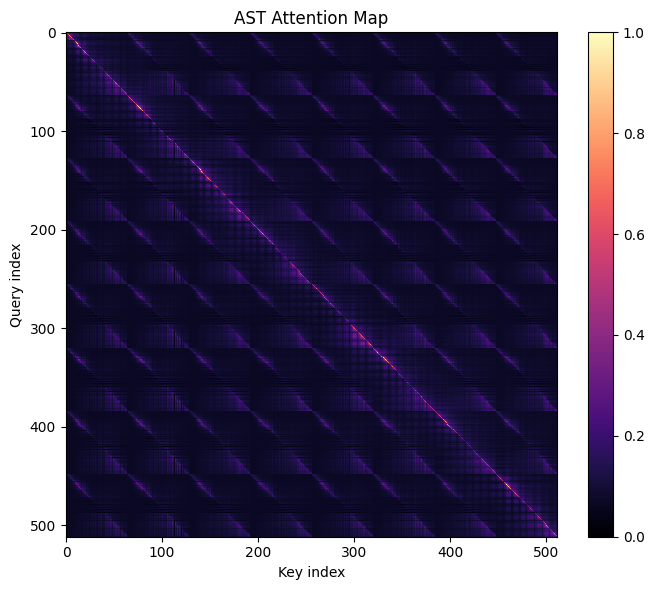

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

path = "/attention_maps/attention_map_vmamba_2_2_all.npy"
attn = np.load(path)

print("shape:", attn.shape, "dtype:", attn.dtype, "min/max:", attn.min(), attn.max())


plt.figure(figsize=(7, 6))
plt.imshow(attn, cmap="magma", aspect="auto", interpolation="nearest")
plt.title("DASS Map")
plt.xlabel("Key index")
plt.ylabel("Query index")
plt.colorbar()
plt.tight_layout()
plt.show()

/tmp/ipython-input-2898114640.py:9: RuntimeWarning: divide by zero encountered in log
  attn_log = np.log(attn)


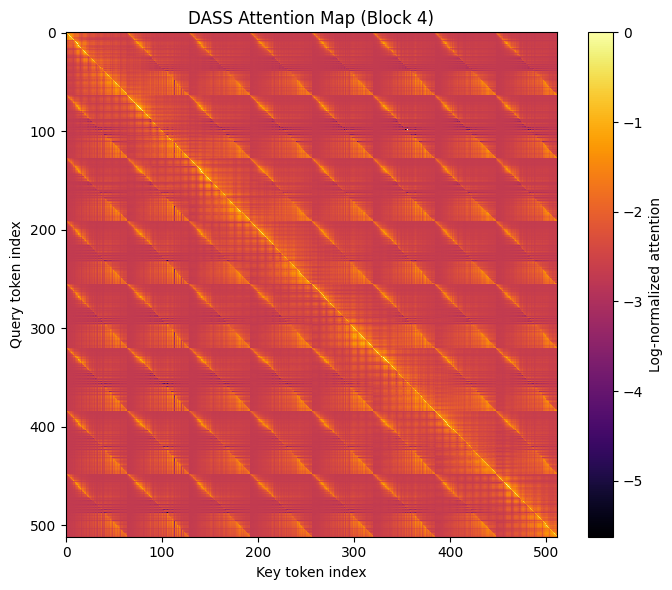

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


npy_path = "/attention_maps/attention_map_vmamba_2_2_all.npy"
attn = np.load(npy_path)


attn_log = np.log(attn)



plt.figure(figsize=(7, 6))
plt.imshow(attn_log, cmap="inferno", interpolation="nearest", aspect="auto")
plt.colorbar(label="Log-normalized attention")
plt.title("DASS Attention Map")
plt.xlabel("Key token index")
plt.ylabel("Query token index")
plt.tight_layout()
plt.show()

loaded: (512, 512) float32


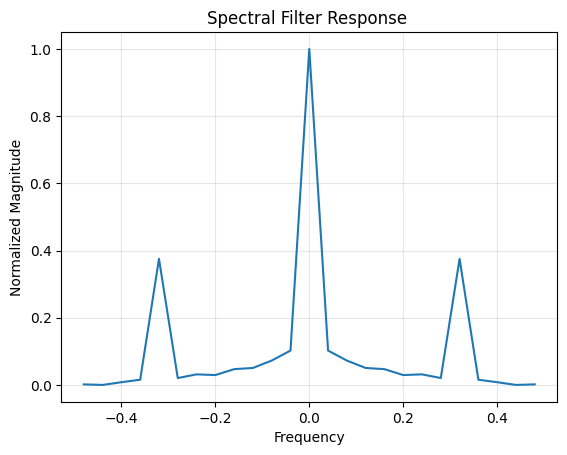

In [ ]:
import numpy as np
import scipy
from scipy.linalg import dft
import matplotlib.pyplot as plt

file_path = "/attention_maps/attention_map_vmamba_2_2_all.npy"
attn = np.load(file_path)
print("loaded:", attn.shape, attn.dtype)

L = attn.shape[0]

def fftshift(arr, n=50):

    freq = scipy.fft.rfftfreq(25)
    x = np.concatenate([np.flip(-freq[1:]), freq])
    y = np.concatenate([np.flip(arr[1:]), arr])

    return x, y

F = dft(L)                 
Finv = np.linalg.inv(F)    

spec = F @ attn @ Finv
spec_1d = np.abs(spec).mean(axis=1)
spec_1d = spec_1d[:13]

x, y = fftshift(spec_1d, n=26)
y = (y - y.min()) / (y.max() - y.min() + 1e-12)

plt.title("Spectral Filter Response ")
plt.xlabel("Frequency")
plt.ylabel("Normalized Magnitude")
plt.plot(x, y)
plt.grid(alpha=0.3)
plt.show()


loaded: (512, 512) float32


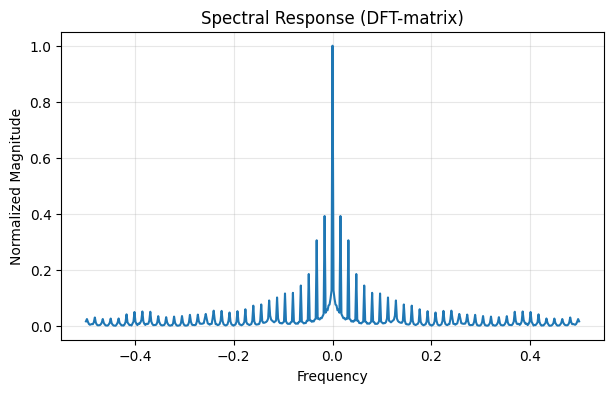

In [ ]:
import numpy as np
import scipy
from scipy.linalg import dft
import matplotlib.pyplot as plt

file_path = "/attention_maps/attention_map_vmamba_2_2_all.npy"
attn = np.load(file_path)
print("loaded:", attn.shape, attn.dtype)

L = attn.shape[0]

def fftshift(arr):
    N = len(arr)
    freq = scipy.fft.rfftfreq(N * 2 - 1)
    x = np.concatenate([np.flip(-freq[1:]), freq])
    y = np.concatenate([np.flip(arr[1:]), arr])
    return x, y

F = dft(L)
Finv = np.linalg.inv(F)

spec = F @ attn @ Finv
spec_1d = np.abs(spec).mean(axis=1)

spec_1d = spec_1d[:250]

x, y = fftshift(spec_1d)
y = (y - y.min()) / (y.max() - y.min() + 1e-12)

plt.figure(figsize=(7,4))
plt.title("Spectral Response (DFT-matrix)")
plt.xlabel("Frequency")
plt.ylabel("Normalized Magnitude")
plt.plot(x, y)
plt.grid(alpha=0.3)
plt.show()

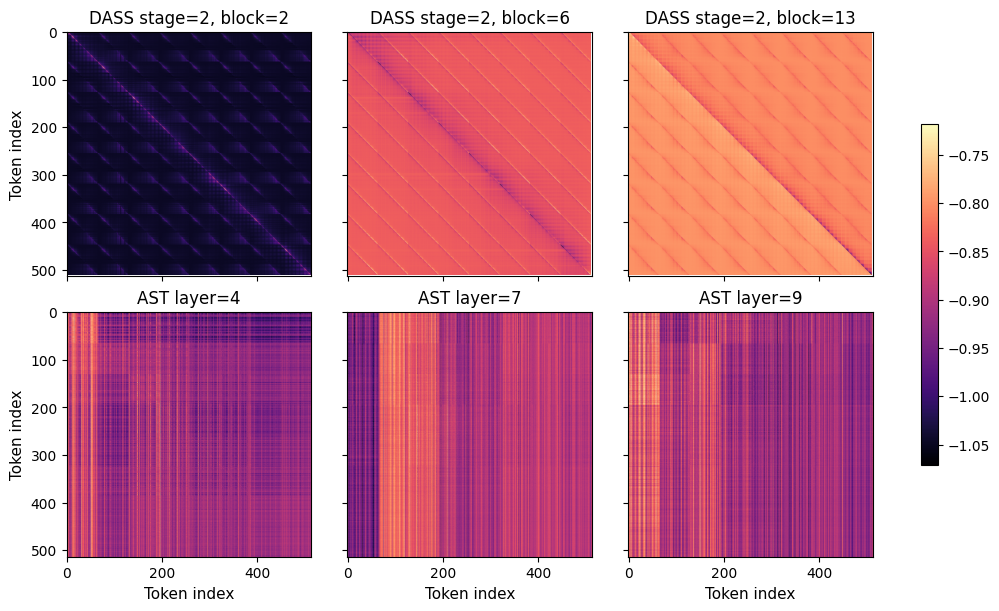

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

root = "/attention_maps/pretrained_models"


vmamba_pairs = [(2, 2), (2, 6), (2, 13)]   

ast_indices = [4, 7, 9]                

fig, axes = plt.subplots(
    2, 3,
    figsize=(10, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for col, (stage, block) in enumerate(vmamba_pairs):
    path = os.path.join(root, f"attention_map_vmamba_{stage}_{block}_all.npy")
    attn = np.load(path)

    attn_t = torch.from_numpy(attn)


    while attn_t.dim() > 2:
        attn_t = attn_t.squeeze(0)          
        if attn_t.dim() > 2:
            attn_t = attn_t.sum(dim=0)     

    attn2d = attn_t.to(torch.float32).cpu().numpy()

    ax = axes[0, col]
    im = ax.imshow(attn2d, cmap="magma", aspect="equal")
    ax.set_title(f"DASS stage={stage}, block={block}")


for col, idx in enumerate(ast_indices):
    path = os.path.join(root, f"attention_map_ast_{idx}.npy")
    attn = np.load(path)

    attn_log = np.log(attn + 1e-7)

    ax = axes[1, col]
    im = ax.imshow(attn_log, cmap="magma", aspect="equal")
    ax.set_title(f"AST layer={idx}")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.65)
cbar.ax.tick_params(labelsize=10)

for ax in axes[:, 0]:
    ax.set_ylabel("Token index", fontsize=11)

for ax in axes[-1, :]:
    ax.set_xlabel("Token index", fontsize=11)

plt.show()

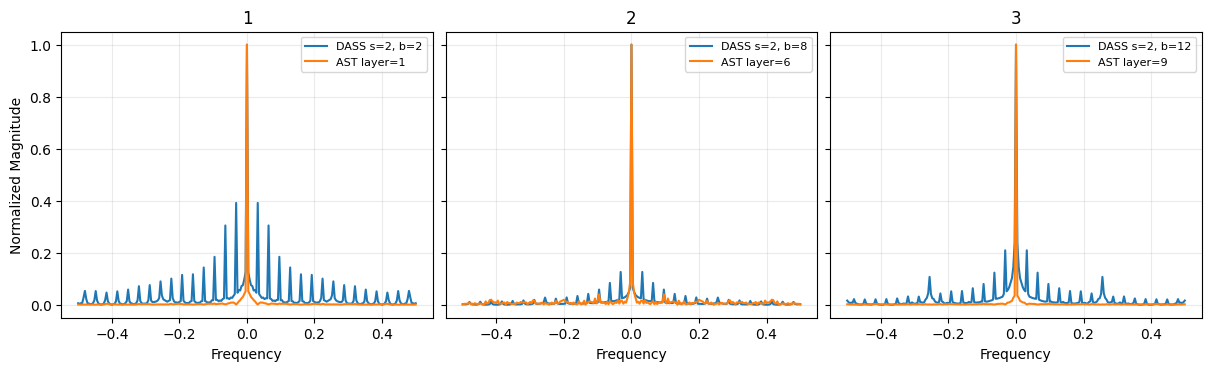

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

root = "/attention_maps/pretrained_models"

vmamba_pairs = [(2,2), (2,8), (2,12)]
ast_indices  = [1, 6, 9]


def reduce_to_2d_attn(attn):

    t = attn
    while t.ndim > 2:
        t = np.squeeze(t, axis=0)
        if t.ndim > 2:
            t = t.sum(axis=0)
    assert t.ndim == 2 and t.shape[0] == t.shape[1]
    return t.astype(np.float64)

def dft_matrix_np(n):
    k = np.arange(n).reshape(n, 1)
    m = np.arange(n).reshape(1, n)
    return np.exp(-2j * np.pi * k * m / n)

def spectral_response_np(attn_2d, n_freq=250, eps=1e-12):

    L = attn_2d.shape[0]

    F = dft_matrix_np(L)
    Finv = np.linalg.inv(F)

    spec = np.abs(F @ attn_2d @ Finv).mean(axis=1)  # (L,)
    K = min((n_freq // 2) + 1, L)
    spec = spec[:K]

    freq = np.fft.rfftfreq(n_freq, d=1.0)  # (K,)
    x = np.concatenate([np.flip(-freq[1:]), freq])
    y = np.concatenate([np.flip(spec[1:]), spec])

    y = (y - y.min()) / (y.max() - y.min() + eps)
    return x, y

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3.6),
    sharey=True,
    constrained_layout=True
)

for col in range(3):

    s, b = vmamba_pairs[col]
    vm_path = os.path.join(root, f"attention_map_vmamba_{s}_{b}_all.npy")
    vm_attn = reduce_to_2d_attn(np.load(vm_path))
    x_vm, y_vm = spectral_response_np(vm_attn)


    idx = ast_indices[col]
    ast_path = os.path.join(root, f"attention_map_ast_{idx}.npy")
    ast_attn = np.log(np.load(ast_path) + 1e-7)
    ast_attn = reduce_to_2d_attn(ast_attn)
    x_ast, y_ast = spectral_response_np(ast_attn)

    ax = axes[col]
    ax.plot(x_vm, y_vm, label=f"DASS s={s}, b={b}")
    ax.plot(x_ast, y_ast, label=f"AST layer={idx}")
    ax.set_title(f"{col+1}")
    ax.set_xlabel("Frequency")
    if col == 0:
        ax.set_ylabel("Normalized Magnitude")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.show()